In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
class RetailAnalyzer:

    def __init__(self):
        self.df = None
        print("Retail Sales Analyzer Initialized Successfully.")
        
    def load_data(self):
        try:
            print("\n== Load Dataset ==")

            file_path = input("Enter CSV file path: ")

            self.df = pd.read_csv(file_path)

            if self.df.empty:
                print("Dataset is empty.")
                return

            print("\nDataset Loaded Successfully.")
            print(f"Rows    : {self.df.shape[0]}")
            print(f"Columns : {self.df.shape[1]}")

        except FileNotFoundError:
            print("Error: File not found.")

        except pd.errors.EmptyDataError:
            print("Error: CSV file is empty.")

        except Exception as e:
            print("Error:", e)

    def display_summary(self):
        try:
            if self.df is None:
                print("Please load the dataset first.")
                return

            print("\n========== DATASET SUMMARY ==========")

            print(f"\nDataset Shape : {self.df.shape}")

            print("\nColumn Names:")
            print(self.df.columns.tolist())

            print("\nData Types:")
            print(self.df.dtypes)

            print("\nMissing Values:")
            print(self.df.isnull().sum())

            print("\nFirst 5 Rows:")
            print(self.df.head())

            print("\nStatistical Summary:")
            print(self.df.describe())

        except Exception as e:
            print("Error:", e)

    def clean_data(self):
        try:
            if self.df is None:
                print("Please load the dataset first.")
                return

            print("\nMissing Values Before Cleaning:")
            print(self.df.isnull().sum())

           
            self.df["Date"] = self.df["Date"].ffill()

            
            self.df["Product"] = self.df["Product"].fillna("Unknown")
            self.df["Category"] = self.df["Category"].fillna("Unknown")

            
            self.df["Price"] = self.df["Price"].fillna(self.df["Price"].mean())

            
            self.df["Quantity Sold"] = self.df["Quantity Sold"].fillna(
                self.df["Quantity Sold"].mean()
            )

            
            self.df["Total Sales"] = self.df["Total Sales"].fillna(
                self.df["Price"] * self.df["Quantity Sold"]
            )

            print("\nMissing Values After Cleaning:")
            print(self.df.isnull().sum())

            print("\nData Cleaned Successfully.")

        except Exception as e:
            print("Error:", e)

    def calculate_metrics(self):
        try:
            if self.df is None:
                print("Please load the dataset first.")
                return

            print("\n== Sales Metrics ==")

            sales = self.df["Total Sales"].dropna().to_numpy()

            print(f"Total Sales      : {np.sum(sales):.2f}")
            print(f"Average Sales    : {np.mean(sales):.2f}")
            print(f"Highest Sale     : {np.max(sales):.2f}")
            print(f"Lowest Sale      : {np.min(sales):.2f}")

            most_sold_product = self.df.groupby("Product")["Quantity Sold"].sum().idxmax()
            most_popular_category = self.df.groupby("Category")["Total Sales"].sum().idxmax()

            print(f"Most Sold Product      : {most_sold_product}")
            print(f"Most Popular Category  : {most_popular_category}")

        except Exception as e:
            print("Error:", e)

    def filter_data(self):
        try:
            if self.df is None:
                print("Please load the dataset first.")
                return

            print("\n== Filter Data ==")
            print("Filter By:")
            print("1. Category")
            print("2. Product")

            choice = input("Enter your choice: ")

            if choice == "1":
                category = input("Enter Category: ")
                filtered = self.df[self.df["Category"].str.lower() == category.lower()]

            elif choice == "2":
                product = input("Enter Product: ")
                filtered = self.df[self.df["Product"].str.lower() == product.lower()]

            else:
                print("Invalid Choice!")
                return

            if filtered.empty:
                print("\nNo matching records found.")
            else:
                print(f"\nTotal Records Found: {len(filtered)}")
                print(filtered.head(10))

        except Exception as e:
            print("Error:", e)


    def bar_chart(self):
        try:
            if self.df is None:
                print("Please load the dataset first.")
                return

            print("\n== Bar Chart : Total Sales by Category ==")

            category_sales = self.df.groupby("Category")["Total Sales"].sum()

            plt.figure(figsize=(6,5))
            plt.bar(category_sales.index, category_sales.values)
            plt.title("Total Sales by Category")
            plt.xlabel("Category")
            plt.ylabel("Total Sales")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print("Error:", e)

    def line_graph(self):
        try:
            if self.df is None:
                print("Please load the dataset first.")
                return

            print("\n== Line Graph : Sales Trend ==")

            
            self.df["Date"] = pd.to_datetime(
                self.df["Date"],
                format="%d-%m-%Y",
                errors="coerce"
            )

            
            sales_trend = (
                self.df.dropna(subset=["Date", "Total Sales"])
                .groupby("Date")["Total Sales"]
                .sum().head(10)
            )

            plt.figure(figsize=(10, 5))
            plt.plot(sales_trend.index, sales_trend.values, marker="o")

            plt.title("Sales Trend Over Time")
            plt.xlabel("Date")
            plt.ylabel("Total Sales")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print("Error:", e)

    def heatmap(self):
        try:
            if self.df is None:
                print("Please load the dataset first.")
                return
    
            print("\n== Heatmap : Correlation Matrix ==")
    
            correlation = self.df[["Price", "Quantity Sold", "Total Sales"]].corr()
    
            plt.figure(figsize=(6, 5))
            sns.heatmap(correlation,
                        annot=True,
                        cmap="coolwarm",
                        linewidths=0.5)
    
            plt.title("Correlation Heatmap")
            plt.tight_layout()
            plt.show()
    
        except Exception as e:
            print("Error:", e)            
                    
    def main_menu(self):

        while True:

            print("\n========== Retail Sales Analyzer ==========")
            print("Please select an option:")
            print("1. Load Dataset")
            print("2. Display Summary")
            print("3. Clean Data")
            print("4. Calculate Metrics")
            print("5. Filter Data")
            print("6. Bar Chart")
            print("7. Line Graph")
            print("8. Heatmap")
            print("9. Exit")
            print("===========================================")

            choice = input("\nEnter your choice: ")

            if choice == "1":
                self.load_data()

            elif choice == "2":
                self.display_summary()

            elif choice == "3":
                self.clean_data()

            elif choice == "4":
                self.calculate_metrics()

            elif choice == "5":
                self.filter_data()

            elif choice == "6":
                self.bar_chart()

            elif choice == "7":
                self.line_graph()

            elif choice == "8":
                self.heatmap()

            elif choice == "9":
                print("\nThank you for using Retail Sales Analyzer.")
                break

            else:
                print("Invalid choice! Please try again.")        

    def __del__(self):
        print("Program closed successfully.")

Retail Sales Analyzer Initialized Successfully.
Program closed successfully.

========== Retail Sales Analyzer ==========
Please select an option:
1. Load Dataset
2. Display Summary
3. Clean Data
4. Calculate Metrics
5. Filter Data
6. Bar Chart
7. Line Graph
8. Heatmap
9. Exit



Enter your choice:  1



== Load Dataset ==


Enter CSV file path:  retail_sales.csv



Dataset Loaded Successfully.
Rows    : 5000
Columns : 6

========== Retail Sales Analyzer ==========
Please select an option:
1. Load Dataset
2. Display Summary
3. Clean Data
4. Calculate Metrics
5. Filter Data
6. Bar Chart
7. Line Graph
8. Heatmap
9. Exit


...


== Filter Data ==
Filter By:
1. Category
2. Product


Enter your choice:  2
Enter Product:  Tablet



Total Records Found: 308
           Date Product     Category     Price  Quantity Sold  Total Sales
15   10-02-2025  Tablet  Electronics  23663.95            2.0     47327.90
22   28-04-2025  Tablet  Electronics  22660.50            6.0    135963.00
37   24-02-2025  Tablet  Electronics  25626.50            9.0    230638.50
62   08-05-2025  Tablet  Electronics  27116.33            8.0    216930.64
108  15-07-2025  Tablet  Electronics  22693.62            8.0    181548.96
135  09-11-2025  Tablet  Electronics  26342.45            8.0    210739.60
143  10-11-2025  Tablet  Electronics  26096.37            9.0    234867.33
144  07-08-2025  Tablet  Electronics  27034.27            8.0    216274.16
160  26-03-2025  Tablet  Electronics  24836.95            3.0     74510.85
167  10-05-2025  Tablet  Electronics  22909.53            1.0     22909.53

========== Retail Sales Analyzer ==========
Please select an option:
1. Load Dataset
2. Display Summary
3. Clean Data
4. Calculate Metrics
5. Filter


Enter your choice:  6



== Bar Chart : Total Sales by Category ==


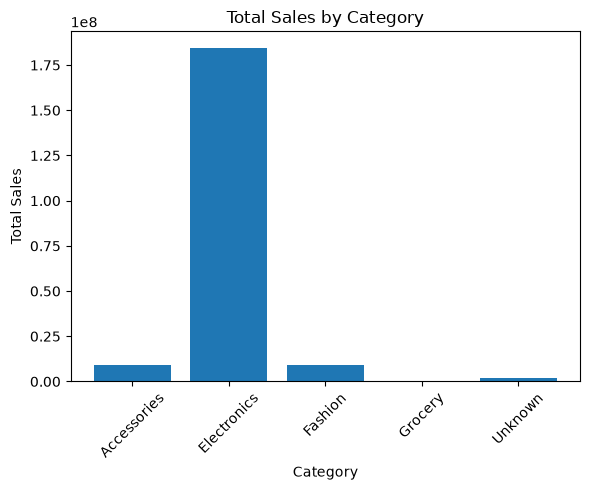


========== Retail Sales Analyzer ==========
Please select an option:
1. Load Dataset
2. Display Summary
3. Clean Data
4. Calculate Metrics
5. Filter Data
6. Bar Chart
7. Line Graph
8. Heatmap
9. Exit



Enter your choice:  7



== Line Graph : Sales Trend ==


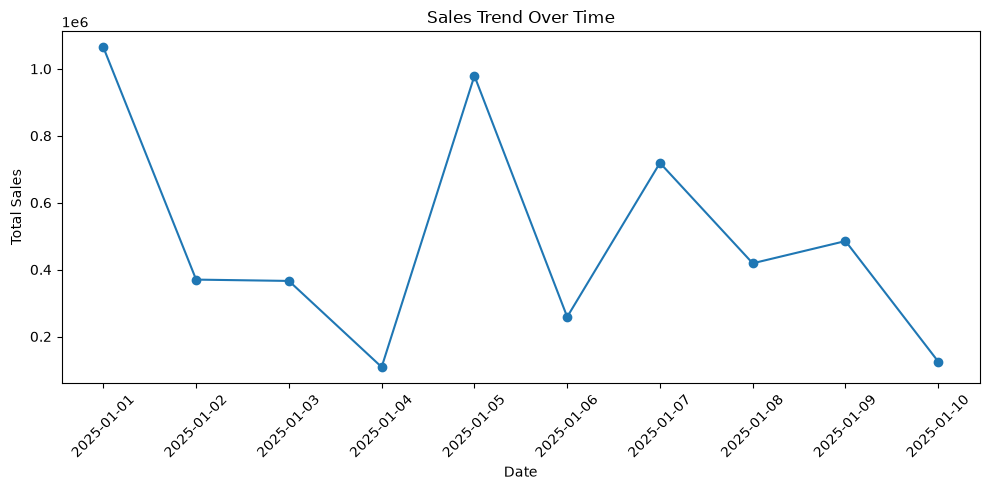


========== Retail Sales Analyzer ==========
Please select an option:
1. Load Dataset
2. Display Summary
3. Clean Data
4. Calculate Metrics
5. Filter Data
6. Bar Chart
7. Line Graph
8. Heatmap
9. Exit



Enter your choice:  8



== Heatmap : Correlation Matrix ==


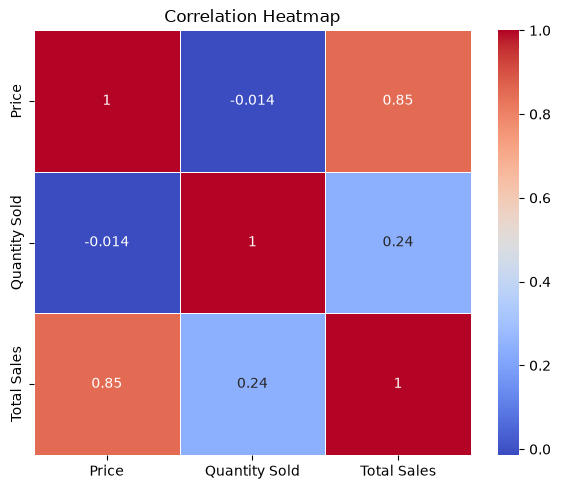


========== Retail Sales Analyzer ==========
Please select an option:
1. Load Dataset
2. Display Summary
3. Clean Data
4. Calculate Metrics
5. Filter Data
6. Bar Chart
7. Line Graph
8. Heatmap
9. Exit



Enter your choice:  9



Thank you for using Retail Sales Analyzer.


In [4]:
obj = RetailAnalyzer()
# obj.load_data()
obj.main_menu()